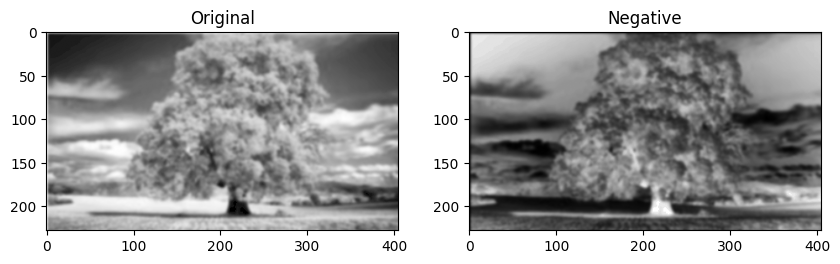

In [2]:
#1. Gray Level Transformations
#(A) Image Negative
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/Screenshot 2026-07-14 171659.png",0)

rows, cols = img.shape

negative = img.copy()

for i in range(rows):
    for j in range(cols):
        negative[i,j] = 255 - img[i,j]

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img,cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(negative,cmap='gray')
plt.title("Negative")

plt.show()

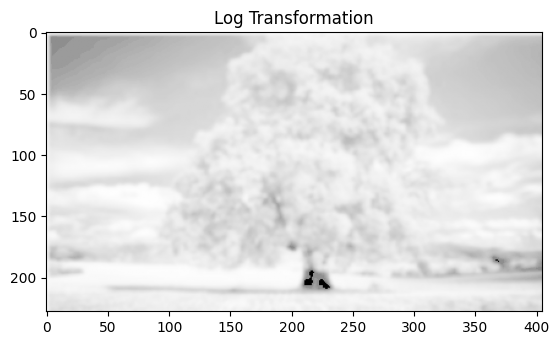

In [3]:
#(B) Log Transformation
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/content/Screenshot 2026-07-14 171659.png",0)

c = 255 / np.log(1 + np.max(img))

rows, cols = img.shape

log_img = np.zeros((rows,cols),dtype=np.uint8)

for i in range(rows):
    for j in range(cols):
        value = c * np.log(1 + img[i,j])
        log_img[i,j] = int(value)

plt.imshow(log_img,cmap='gray')
plt.title("Log Transformation")
plt.show()

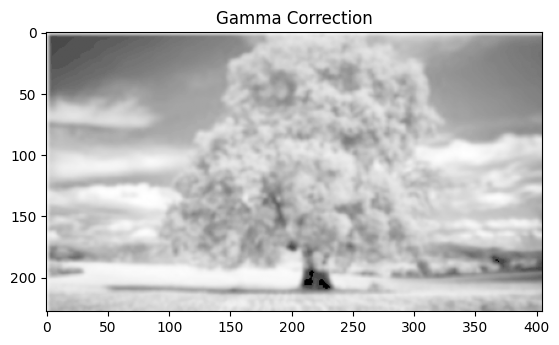

In [5]:
#(C) Gamma Transformation
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/content/Screenshot 2026-07-14 171659.png",0)

gamma = 0.5

rows, cols = img.shape

result = np.zeros((rows,cols),dtype=np.uint8)

for i in range(rows):
    for j in range(cols):
        pixel = img[i,j]/255
        value = 255*(pixel**gamma)
        result[i,j]=int(value)

plt.imshow(result,cmap='gray')
plt.title("Gamma Correction")
plt.show()

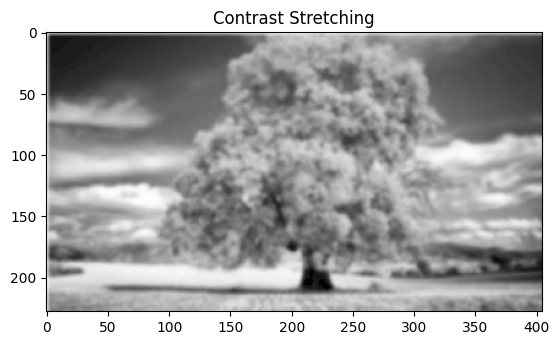

In [7]:
#(D) Contrast Stretching
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/content/Screenshot 2026-07-14 171659.png",0)

rmin = np.min(img)
rmax = np.max(img)

rows,cols = img.shape

stretch = np.zeros((rows,cols),dtype=np.uint8)

for i in range(rows):
    for j in range(cols):
        stretch[i,j]=((img[i,j]-rmin)/(rmax-rmin))*255

plt.imshow(stretch,cmap='gray')
plt.title("Contrast Stretching")
plt.show()

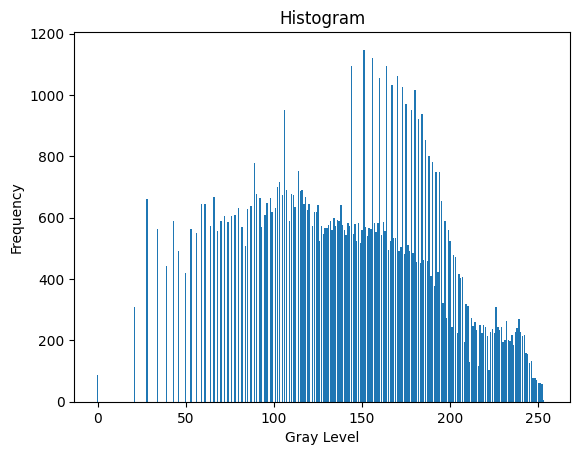

In [8]:
#2. Histogram Processing
#Manual Histogram Calculation
import cv2
import matplotlib.pyplot as plt

img=cv2.imread("/content/Screenshot 2026-07-14 171659.png",0)

hist=[0]*256

rows,cols=img.shape

for i in range(rows):
    for j in range(cols):
        pixel=img[i,j]
        hist[pixel]+=1

plt.bar(range(256),hist)
plt.title("Histogram")
plt.xlabel("Gray Level")
plt.ylabel("Frequency")
plt.show()

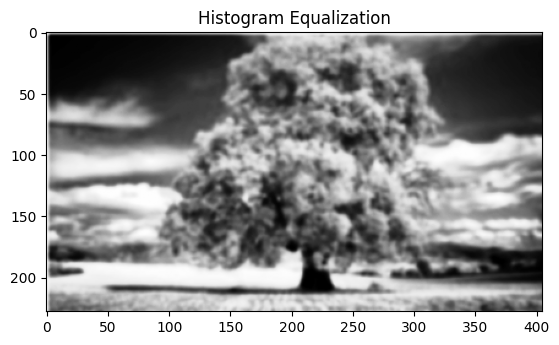

In [9]:
#Manual Histogram Equalization
import cv2
import numpy as np
import matplotlib.pyplot as plt

img=cv2.imread("/content/Screenshot 2026-07-14 171659.png",0)

rows,cols=img.shape

hist=[0]*256

for i in range(rows):
    for j in range(cols):
        hist[img[i,j]]+=1

cdf=[]

sum=0

for value in hist:
    sum+=value
    cdf.append(sum)

cdf=np.array(cdf)

cdf=(cdf-cdf.min())*255/(cdf.max()-cdf.min())

cdf=cdf.astype('uint8')

equalized=np.zeros((rows,cols),dtype=np.uint8)

for i in range(rows):
    for j in range(cols):
        equalized[i,j]=cdf[img[i,j]]

plt.imshow(equalized,cmap='gray')
plt.title("Histogram Equalization")
plt.show()

/tmp/ipykernel_822/3043498353.py:20: RuntimeWarning: overflow encountered in scalar add
  total+=img[i+x,j+y]


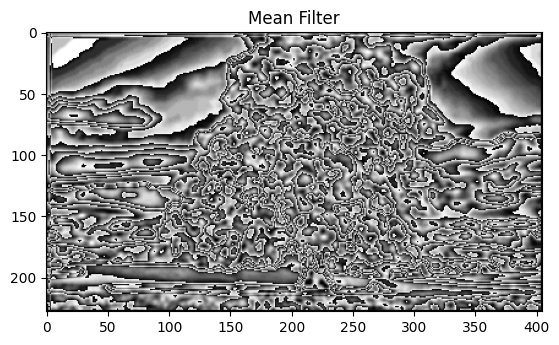

In [10]:
#3. Spatial Filtering
#Manual Mean Filter
import cv2
import numpy as np
import matplotlib.pyplot as plt

img=cv2.imread("/content/Screenshot 2026-07-14 171659.png",0)

rows,cols=img.shape

output=np.zeros((rows,cols),dtype=np.uint8)

for i in range(1,rows-1):
    for j in range(1,cols-1):

        total=0

        for x in range(-1,2):
            for y in range(-1,2):
                total+=img[i+x,j+y]

        output[i,j]=total//9

plt.imshow(output,cmap='gray')
plt.title("Mean Filter")
plt.show()

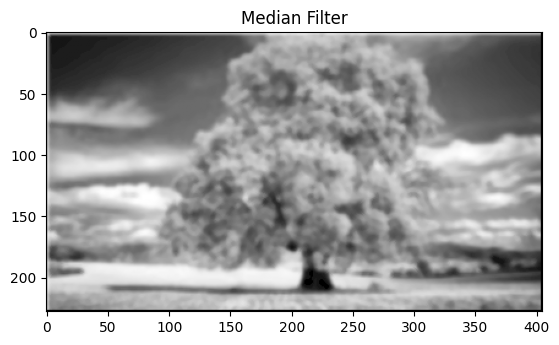

In [11]:
#Manual Median Filter
import cv2
import numpy as np
import matplotlib.pyplot as plt

img=cv2.imread("/content/Screenshot 2026-07-14 171659.png",0)

rows,cols=img.shape

output=np.zeros((rows,cols),dtype=np.uint8)

for i in range(1,rows-1):
    for j in range(1,cols-1):

        values=[]

        for x in range(-1,2):
            for y in range(-1,2):
                values.append(img[i+x,j+y])

        values.sort()

        output[i,j]=values[4]

plt.imshow(output,cmap='gray')
plt.title("Median Filter")
plt.show()

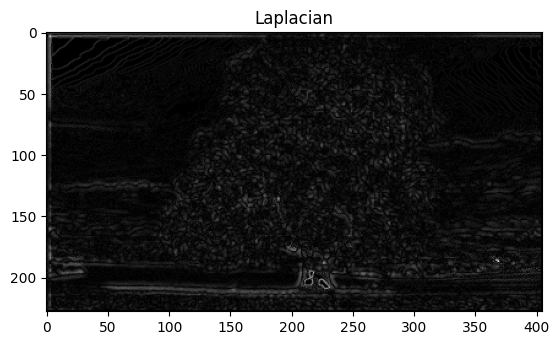

In [15]:
#Manual Laplacian Sharpening
import cv2
import numpy as np
import matplotlib.pyplot as plt

img=cv2.imread("/content/Screenshot 2026-07-14 171659.png",0).astype(np.int16)

kernel=[[0,-1,0],
        [-1,4,-1],
        [0,-1,0]]

rows,cols=img.shape

output=np.zeros((rows,cols),dtype=np.uint8)

for i in range(1,rows-1):
    for j in range(1,cols-1):

        value=0

        for x in range(-1,2):
            for y in range(-1,2):
                value+=img[i+x,j+y]*kernel[x+1][y+1]

        output[i,j]=min(max(abs(value),0),255)

plt.imshow(output,cmap='gray')
plt.title("Laplacian")
plt.show()

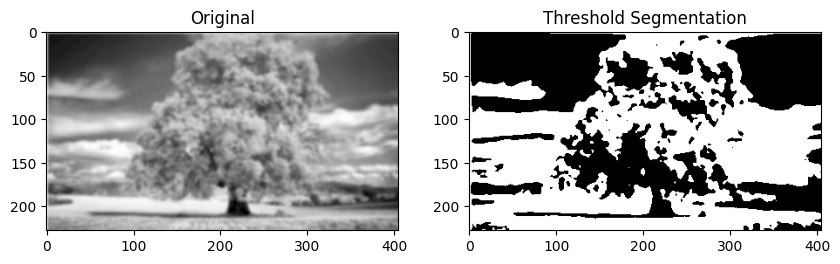

In [16]:
#Types of Image Segmentation
#1. Threshold Segmentation (Otsu Thresholding)
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('/content/Screenshot 2026-07-14 171659.png',0)

rows, cols = img.shape

hist = [0]*256

for i in range(rows):
    for j in range(cols):
        hist[img[i,j]] += 1

total = rows*cols

sum_total = 0
for i in range(256):
    sum_total += i*hist[i]

sumB = 0
wB = 0
maximum = 0
threshold = 0

for t in range(256):

    wB += hist[t]

    if wB == 0:
        continue

    wF = total - wB

    if wF == 0:
        break

    sumB += t*hist[t]

    mB = sumB/wB
    mF = (sum_total-sumB)/wF

    variance = wB*wF*((mB-mF)**2)

    if variance > maximum:
        maximum = variance
        threshold = t

output = np.zeros((rows,cols),dtype=np.uint8)

for i in range(rows):
    for j in range(cols):

        if img[i,j] > threshold:
            output[i,j]=255
        else:
            output[i,j]=0

plt.figure(figsize=(10,5))

plt.subplot(121)
plt.imshow(img,cmap='gray')
plt.title("Original")

plt.subplot(122)
plt.imshow(output,cmap='gray')
plt.title("Threshold Segmentation")

plt.show()

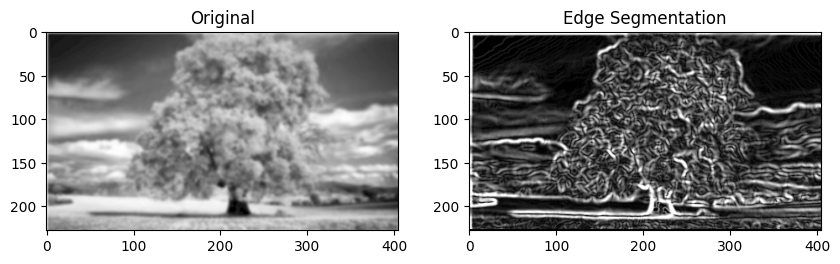

In [18]:
#2. Edge-Based Segmentation (Sobel Operator)
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('/content/Screenshot 2026-07-14 171659.png',0).astype(np.int16)

rows, cols = img.shape

gx = [[-1,0,1],
      [-2,0,2],
      [-1,0,1]]

gy = [[1,2,1],
      [0,0,0],
      [-1,-2,-1]]

output = np.zeros((rows,cols),dtype=np.uint8)

for i in range(1,rows-1):
    for j in range(1,cols-1):

        sx = 0
        sy = 0

        for x in range(-1,2):
            for y in range(-1,2):

                sx += img[i+x,j+y]*gx[x+1][y+1]
                sy += img[i+x,j+y]*gy[x+1][y+1]

        value = abs(sx)+abs(sy)

        if value>255:
            value=255

        output[i,j]=value

plt.figure(figsize=(10,5))

plt.subplot(121)
plt.imshow(img,cmap='gray')
plt.title("Original")

plt.subplot(122)
plt.imshow(output,cmap='gray')
plt.title("Edge Segmentation")

plt.show()

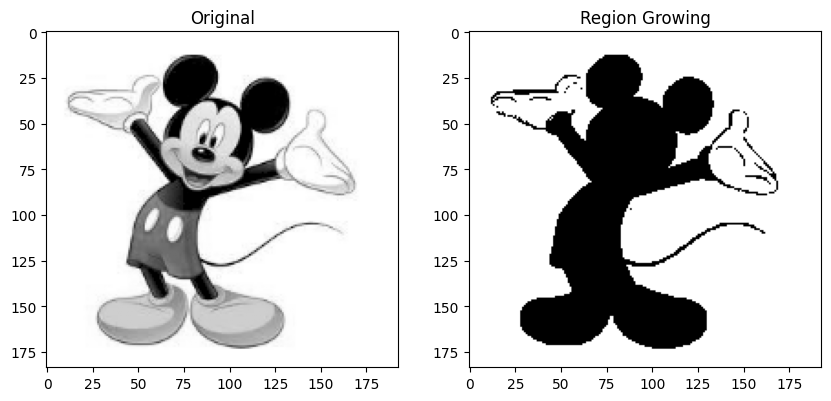

In [20]:
#3. Region-Based Segmentation (Region Growing)
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/content/Screenshot 2026-02-26 140552.png",0)

rows, cols = img.shape

visited = np.zeros((rows,cols),dtype=np.uint8)

seed = (100,100)

threshold = 15

stack = [seed]

while stack:

    x,y = stack.pop()

    if x<0 or y<0 or x>=rows or y>=cols:
        continue

    if visited[x,y]==255:
        continue

    visited[x,y]=255

    current = img[x,y]

    for dx in [-1,0,1]:
        for dy in [-1,0,1]:

            nx = x+dx
            ny = y+dy

            if 0<=nx<rows and 0<=ny<cols:

                if abs(int(img[nx,ny])-int(current))<threshold:
                    stack.append((nx,ny))

plt.figure(figsize=(10,5))

plt.subplot(121)
plt.imshow(img,cmap='gray')
plt.title("Original")

plt.subplot(122)
plt.imshow(visited,cmap='gray')
plt.title("Region Growing")

plt.show()

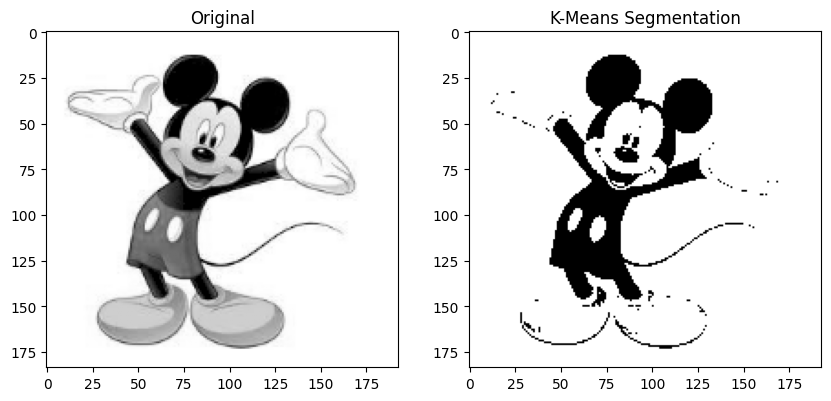

In [24]:
#4. Clustering-Based Segmentation (K-Means from Scratch)
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/content/Screenshot 2026-02-26 140552.png",0).astype(np.int16)

pixels = img.flatten()

k = 2

centroids = [50,200]

for iteration in range(10):

    cluster1=[]
    cluster2=[]

    for pixel in pixels:

        if abs(pixel-centroids[0]) < abs(pixel-centroids[1]):
            cluster1.append(pixel)
        else:
            cluster2.append(pixel)

    if len(cluster1)>0:
        centroids[0]=np.mean(cluster1)

    if len(cluster2)>0:
        centroids[1]=np.mean(cluster2)

output=[]

for pixel in pixels:

    if abs(pixel-centroids[0])<abs(pixel-centroids[1]):
        output.append(0)
    else:
        output.append(255)

output=np.array(output,dtype=np.uint8)

output=output.reshape(img.shape)

plt.figure(figsize=(10,5))

plt.subplot(121)
plt.imshow(img,cmap='gray')
plt.title("Original")

plt.subplot(122)
plt.imshow(output,cmap='gray')
plt.title("K-Means Segmentation")

plt.show()